# Statistics in Machine Learning

## Data Cleaning
What is Data Cleaning?

Data Cleaning is the process of finding and correcting incorrect, incomplete, duplicate, or inconsistent data before using it for analysis or Machine Learning.

**Data Cleaning = Making raw data clean, correct, and ready for Machine Learning**.
### Example
Suppose we have employee ages:
22, 25, 28, 30, 32, 35, 200

In [1]:
import pandas as pd

data = {
    "Age": [22, 25, 28, 30, 32, 35, 200]
}

df = pd.DataFrame(data)

print(df.describe())

              Age
count    7.000000
mean    53.142857
std     64.901024
min     22.000000
25%     26.500000
50%     30.000000
75%     33.500000
max    200.000000


## Missing Value Handling
What is Missing Value Handling?

Missing Value Handling is the process of identifying and dealing with empty or unavailable values in a dataset.
### Example
| Age | Salary |
|---:|---:|
| 22 | 25000 |
| 25 | 30000 |
| NaN | 35000 |
| 30 | 40000 |


In [2]:
import pandas as pd

data = {
    "Age": [20, 22, 24, 26, None]
}

df = pd.DataFrame(data)

df["Age"] = df["Age"].fillna(df["Age"].mean())

print(df)

    Age
0  20.0
1  22.0
2  24.0
3  26.0
4  23.0


## Outlier Detection
What is an Outlier?

An outlier is a data value that is significantly different from most of the other values in a dataset.
tatistics provides several methods for detecting outliers:
- IQR method
- Z-score method
- Box Plot
  #### The two important methods are:

- IQR Method
- Z-Score Method

In [9]:
import pandas as pd

data = {
    "Salary": [25000, 28000, 30000, 32000, 35000, 34000, 500000]
}

df = pd.DataFrame(data)

Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 29000.0
Q3: 34500.0
IQR: 5500.0
Lower Limit: 20750.0
Upper Limit: 42750.0


In [10]:
outliers = df[
    (df["Salary"] < lower_limit) |
    (df["Salary"] > upper_limit)
]

print("Outliers:")
print(outliers)

Outliers:
   Salary
6  500000


#### 2. Z-Score Method
A Z-score tells us how far a value is from the mean in terms of standard deviations.

Formula:
Z=
σ
X−μ
	​


Where:

X = data value
μ = mean
σ = standard deviation


In [12]:
import numpy as np
from scipy.stats import zscore

data = [10, 12, 11, 13, 14, 15, 100]

z_scores = zscore(data)

print(z_scores)

[-0.48924605 -0.42401325 -0.45662965 -0.39139684 -0.35878044 -0.32616404
  2.44623027]


In [13]:
outliers = np.array(data)[np.abs(z_scores) > 3]

print("Outliers:", outliers)

Outliers: []


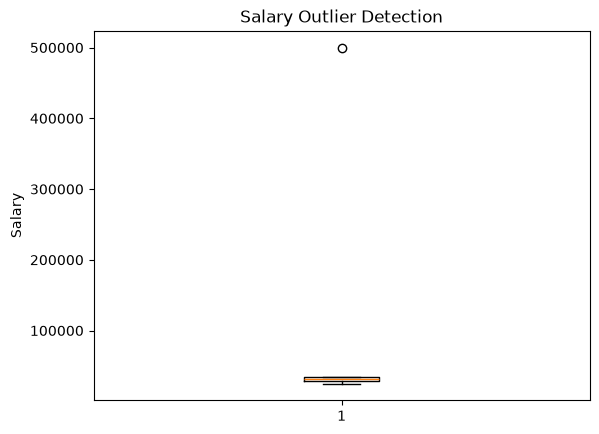

In [14]:
import matplotlib.pyplot as plt

plt.boxplot(df["Salary"])
plt.title("Salary Outlier Detection")
plt.ylabel("Salary")
plt.show()

## Feature Engineering
#### What is Feature Engineering?

Feature Engineering is the process of creating, transforming, or selecting useful features from existing data to help a Machine Learning model learn better.
Standardization

Standardization converts data using:

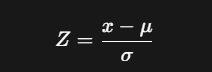

Where:

- x = original value
- μ = mean
- σ = standard deviation

In [16]:
from sklearn.preprocessing import StandardScaler

data = [[20, 25000],
        [30, 40000],
        [40, 60000]]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data)

[[-1.22474487 -1.16247639]
 [ 0.         -0.11624764]
 [ 1.22474487  1.27872403]]


## Data Normalization

What is Data Normalization?

Data Normalization is the process of transforming numerical data into a common scale so that features with different ranges can be compared and used effectively by Machine Learning algorithms.
#### The Min-Max formula is:
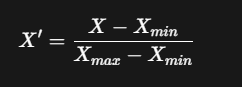


In [17]:
from sklearn.preprocessing import MinMaxScaler

data = [[10], [20], [30], [40], [50]]

scaler = MinMaxScaler()

normalized = scaler.fit_transform(data)

print(normalized)

[[0.  ]
 [0.25]
 [0.5 ]
 [0.75]
 [1.  ]]


## Model Evaluation
What is Model Evaluation?

Model Evaluation is the process of measuring how well a Machine Learning model performs on data.
### Example
Suppose a model predicts whether customers will leave a company.
Actual:    1  0  1  1  0
Predicted: 1  0  0  1  0


In [18]:
from sklearn.metrics import accuracy_score

actual = [1, 0, 1, 1, 0]
predicted = [1, 0, 0, 1, 0]

accuracy = accuracy_score(actual, predicted)

print("Accuracy:", accuracy)

Accuracy: 0.8


## Linear Regression
Linear Regression is a supervised Machine Learning algorithm used to predict a continuous numerical value based on one or more input features.
#### Formula

For one input feature, the equation is:

$$ y = mx + c $$

Where:

y = predicted value
x = input feature
m = slope
c = intercept
### Examples

Linear Regression can be used to predict:

- House price
- Employee salary
- Sales
- Temperature
- Customer spending
- Product demand

In [19]:
from sklearn.linear_model import LinearRegression

X = [[1], [2], [3], [4], [5]]
y = [25000, 30000, 35000, 40000, 45000]

model = LinearRegression()

model.fit(X, y)

prediction = model.predict([[6]])

print("Predicted Salary:", prediction[0])

Predicted Salary: 50000.0


## Logistic Regression
What is Logistic Regression?

Logistic Regression is a supervised Machine Learning algorithm mainly used for classification problems.
##### ommonly used to predict categories such as:

- Yes / No
- Pass / Fail
- Spam / Not Spam
- Fraud / Not Fraud
- Disease / No Disease
- Customer Churn / No Churn
### Example:
Probability = 0.85

In [21]:
from sklearn.linear_model import LogisticRegression

X = [[1], [2], [3], [4], [5], [6]]
y = [0, 0, 0, 1, 1, 1]

model = LogisticRegression()

model.fit(X, y)

prediction = model.predict([[5]])

print("Prediction:", prediction[0])

Prediction: 1


## Naive Bayes
What is Naive Bayes?

Naive Bayes is a supervised Machine Learning algorithm mainly used for classification problems.

It is based on Bayes' Theorem, which uses probability to predict the most likely class for a given observation.
##### Bayes' theorem:
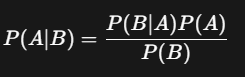
#### It is commonly used for:

- Spam detection
- Text classification
- Sentiment analysis
- News classification
- Document classification
- Medical diagnosis
- Recommendation systems
  

In [22]:
from sklearn.naive_bayes import GaussianNB

X = [[1], [2], [3], [8], [9], [10]]
y = [0, 0, 0, 1, 1, 1]

model = GaussianNB()

model.fit(X, y)

prediction = model.predict([[9]])

print("Prediction:", prediction[0])

Prediction: 1


## Clustering
What is Clustering?

Clustering is an unsupervised machine learning technique used to group similar data points together.

In clustering, we do not provide predefined labels. The algorithm looks at the data and finds groups based on similarity.


In [23]:
from sklearn.cluster import KMeans

X = [
    [20, 20],
    [22, 25],
    [25, 22],
    [50, 80],
    [55, 85],
    [52, 90]
]

model = KMeans(n_clusters=2, random_state=42, n_init=10)

model.fit(X)

print("Cluster Labels:", model.labels_)

Cluster Labels: [0 0 0 1 1 1]


## Principal Component Analysis (PCA)
Principal Component Analysis (PCA) is a statistical technique used for dimensionality reduction.

In simple words, PCA takes a dataset with many features and transforms them into a smaller number of new features called Principal Components, while trying to preserve as much important information as possible.
##### Statistical Concepts Used
PCA uses:
- Mean
- Variance
- Covariance
- Correlation
- Eigenvalues
- Eigenvectors
The main idea is to find directions where the data has the greatest variance.


In [24]:
from sklearn.decomposition import PCA

X = [
    [2, 4, 5],
    [3, 6, 7],
    [4, 8, 9],
    [5, 10, 11]
]

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X)

print(X_reduced)

[[-4.5  0. ]
 [-1.5  0. ]
 [ 1.5  0. ]
 [ 4.5 -0. ]]


## Recommendation Systems
What is a Recommendation System?

A Recommendation System is a machine learning system that suggests products, movies, songs, videos, or other items that a user may be interested in.

### Example

| User | Movie A | Movie B | Movie C |
|---|---:|---:|---:|
| User 1 | 5 | 4 | 1 |
| User 2 | 5 | 4 | 2 |
| User 3 | 1 | 2 | 5 |

In [26]:
import pandas as pd

ratings = pd.DataFrame({
    "Movie_A": [5, 5, 1],
    "Movie_B": [4, 4, 2],
    "Movie_C": [1, 2, 5]
}, index=["User1", "User2", "User3"])

print(ratings.corr())

          Movie_A   Movie_B   Movie_C
Movie_A  1.000000  1.000000 -0.970725
Movie_B  1.000000  1.000000 -0.970725
Movie_C -0.970725 -0.970725  1.000000


In [27]:
import pandas as pd

data = {
    "Experience": [1, 3, 5, 8, 10],
    "Salary": [25000, 32000, 40000, 55000, 65000]
}

df = pd.DataFrame(data)

correlation = df["Experience"].corr(df["Salary"])

print("Experience-Salary Correlation:", correlation)

Experience-Salary Correlation: 0.9973609052511714
